# IE410 - Advanced Computer Programming
# Study-1: Data Preparation and Preprocessing

**Student:** Ibrahim Hakki Keles  
**Project:** Diabetes Prediction (CDC Health Indicators)  
**Date:** April 2026  

---

## 1. Project Topic & Motivation

My project focuses on **predicting diabetes using both medical and socioeconomic factors**.

### Why is this important?
- Diabetes affects over **537 million** adults worldwide (IDF, 2021)
- Research shows that **lifestyle and socioeconomic factors** (smoking, diet, income, education) are as important as clinical measurements
- A predictive model can help **identify high-risk individuals** before symptoms appear

### What makes this project unique?
Unlike the classic Pima Indians dataset (768 patients, only medical data), I am using the **CDC Behavioral Risk Factor Surveillance System (BRFSS) 2015** dataset which includes:
- **Medical factors:** BMI, blood pressure, cholesterol
- **Lifestyle factors:** smoking, physical activity, diet (fruits/vegetables), alcohol consumption
- **Socioeconomic factors:** education level, income level, healthcare access
- **253,680 survey responses** (vs. 768 in Pima)

This is a **binary classification** problem: Does this person have diabetes? (Yes / No)

## 2. Dataset Information

- **Source:** [UCI ML Repository](https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators) / [Kaggle](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset)
- **Original Provider:** CDC (Centers for Disease Control and Prevention) - BRFSS 2015
- **Size:** 253,680 responses x 22 columns
- **Target Variable:** `Diabetes_binary` (1 = Diabetes/Prediabetes, 0 = No Diabetes)

### Feature Categories:

| Category | Features |
|----------|----------|
| **Medical** | HighBP, HighChol, CholCheck, BMI, Stroke, HeartDiseaseorAttack |
| **Lifestyle** | Smoker, PhysActivity, Fruits, Veggies, HvyAlcoholConsump |
| **Socioeconomic** | Education, Income, AnyHealthcare, NoDocbcCost |
| **Health Status** | GenHlth, MentHlth, PhysHlth, DiffWalk |
| **Demographic** | Sex, Age |

## 3. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 4. Loading the Dataset

In [2]:
df = pd.read_csv('../data/raw/cdc_diabetes_health_indicators.csv')

print(f'Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'This is {df.shape[0] // 768}x larger than the Pima Indians dataset!')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB')

Dataset Shape: 253,680 rows x 22 columns
This is 330x larger than the Pima Indians dataset!
Memory usage: 42.6 MB


## 5. Data Exploration

### 5.1 First Look

In [3]:
df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


### 5.2 Column Descriptions

In [4]:
column_info = {
    'HighBP': ('Medical', 'High Blood Pressure (0=No, 1=Yes)'),
    'HighChol': ('Medical', 'High Cholesterol (0=No, 1=Yes)'),
    'CholCheck': ('Medical', 'Cholesterol check in last 5 years (0=No, 1=Yes)'),
    'BMI': ('Medical', 'Body Mass Index'),
    'Smoker': ('Lifestyle', 'Smoked at least 100 cigarettes in life (0=No, 1=Yes)'),
    'Stroke': ('Medical', 'Ever had a stroke (0=No, 1=Yes)'),
    'HeartDiseaseorAttack': ('Medical', 'Heart disease or heart attack (0=No, 1=Yes)'),
    'PhysActivity': ('Lifestyle', 'Physical activity in past 30 days (0=No, 1=Yes)'),
    'Fruits': ('Lifestyle', 'Consume fruit 1+ times per day (0=No, 1=Yes)'),
    'Veggies': ('Lifestyle', 'Consume vegetables 1+ times per day (0=No, 1=Yes)'),
    'HvyAlcoholConsump': ('Lifestyle', 'Heavy alcohol consumption (0=No, 1=Yes)'),
    'AnyHealthcare': ('Socioeconomic', 'Have any health coverage (0=No, 1=Yes)'),
    'NoDocbcCost': ('Socioeconomic', 'Could not see doctor due to cost (0=No, 1=Yes)'),
    'GenHlth': ('Health Status', 'General health (1=Excellent to 5=Poor)'),
    'MentHlth': ('Health Status', 'Days of poor mental health in past 30 days'),
    'PhysHlth': ('Health Status', 'Days of poor physical health in past 30 days'),
    'DiffWalk': ('Health Status', 'Difficulty walking or climbing stairs (0=No, 1=Yes)'),
    'Sex': ('Demographic', 'Sex (0=Female, 1=Male)'),
    'Age': ('Demographic', 'Age category (1=18-24 to 13=80+)'),
    'Education': ('Socioeconomic', 'Education level (1=No school to 6=College graduate)'),
    'Income': ('Socioeconomic', 'Income level (1=<$10k to 8=$75k+)'),
    'Diabetes_binary': ('TARGET', 'Diabetes (0=No, 1=Yes)')
}

print(f'{"Column":25s} {"Category":15s} {"Description"}')
print('=' * 85)
for col, (cat, desc) in column_info.items():
    print(f'{col:25s} {cat:15s} {desc}')

Column                    Category        Description
HighBP                    Medical         High Blood Pressure (0=No, 1=Yes)
HighChol                  Medical         High Cholesterol (0=No, 1=Yes)
CholCheck                 Medical         Cholesterol check in last 5 years (0=No, 1=Yes)
BMI                       Medical         Body Mass Index
Smoker                    Lifestyle       Smoked at least 100 cigarettes in life (0=No, 1=Yes)
Stroke                    Medical         Ever had a stroke (0=No, 1=Yes)
HeartDiseaseorAttack      Medical         Heart disease or heart attack (0=No, 1=Yes)
PhysActivity              Lifestyle       Physical activity in past 30 days (0=No, 1=Yes)
Fruits                    Lifestyle       Consume fruit 1+ times per day (0=No, 1=Yes)
Veggies                   Lifestyle       Consume vegetables 1+ times per day (0=No, 1=Yes)
HvyAlcoholConsump         Lifestyle       Heavy alcohol consumption (0=No, 1=Yes)
AnyHealthcare             Socioeconomic   H

### 5.3 Data Types and Missing Values

In [5]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Missing Values ===')
missing = df.isnull().sum()
print(f'Total missing values: {missing.sum()}')
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print('No missing values found!')

=== Data Types ===
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
Diabetes_binary         int64
dtype: object

=== Missing Values ===
Total missing values: 0
No missing values found!


### 5.4 Statistical Summary

In [6]:
df.describe().round(2)

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,...,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
mean,0.43,0.42,0.96,28.38,0.44,0.04,0.09,0.76,0.63,0.81,...,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05,0.14
std,0.49,0.49,0.19,6.61,0.50,0.20,0.29,0.43,0.48,0.39,...,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07,0.35
min,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00
25%,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,1.00,...,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00,0.00
50%,0.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,1.00,...,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00,0.00
75%,1.00,1.00,1.00,31.00,1.00,0.00,0.00,1.00,1.00,1.00,...,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00,0.00
max,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00,1.00


## 6. Target Variable Analysis

Diabetes Distribution:
  No Diabetes (0):  218,334 (86.1%)
  Diabetes (1):      35,346 (13.9%)


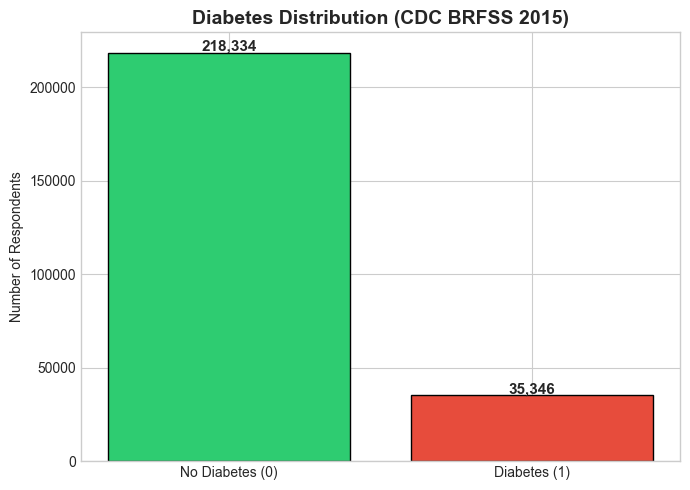

In [7]:
target_counts = df['Diabetes_binary'].value_counts()
target_pct = df['Diabetes_binary'].value_counts(normalize=True) * 100

print('Diabetes Distribution:')
print(f'  No Diabetes (0):  {target_counts[0]:>7,} ({target_pct[0]:.1f}%)')
print(f'  Diabetes (1):     {target_counts[1]:>7,} ({target_pct[1]:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2ecc71', '#e74c3c']
labels = ['No Diabetes (0)', 'Diabetes (1)']
bars = ax.bar(labels, target_counts.values, color=colors, edgecolor='black')
ax.set_title('Diabetes Distribution (CDC BRFSS 2015)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Respondents')
for bar, count in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{count:,}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Feature Analysis by Category

This is what makes our dataset special - we can analyze diabetes from multiple perspectives.

### 7.1 Lifestyle Factors vs Diabetes

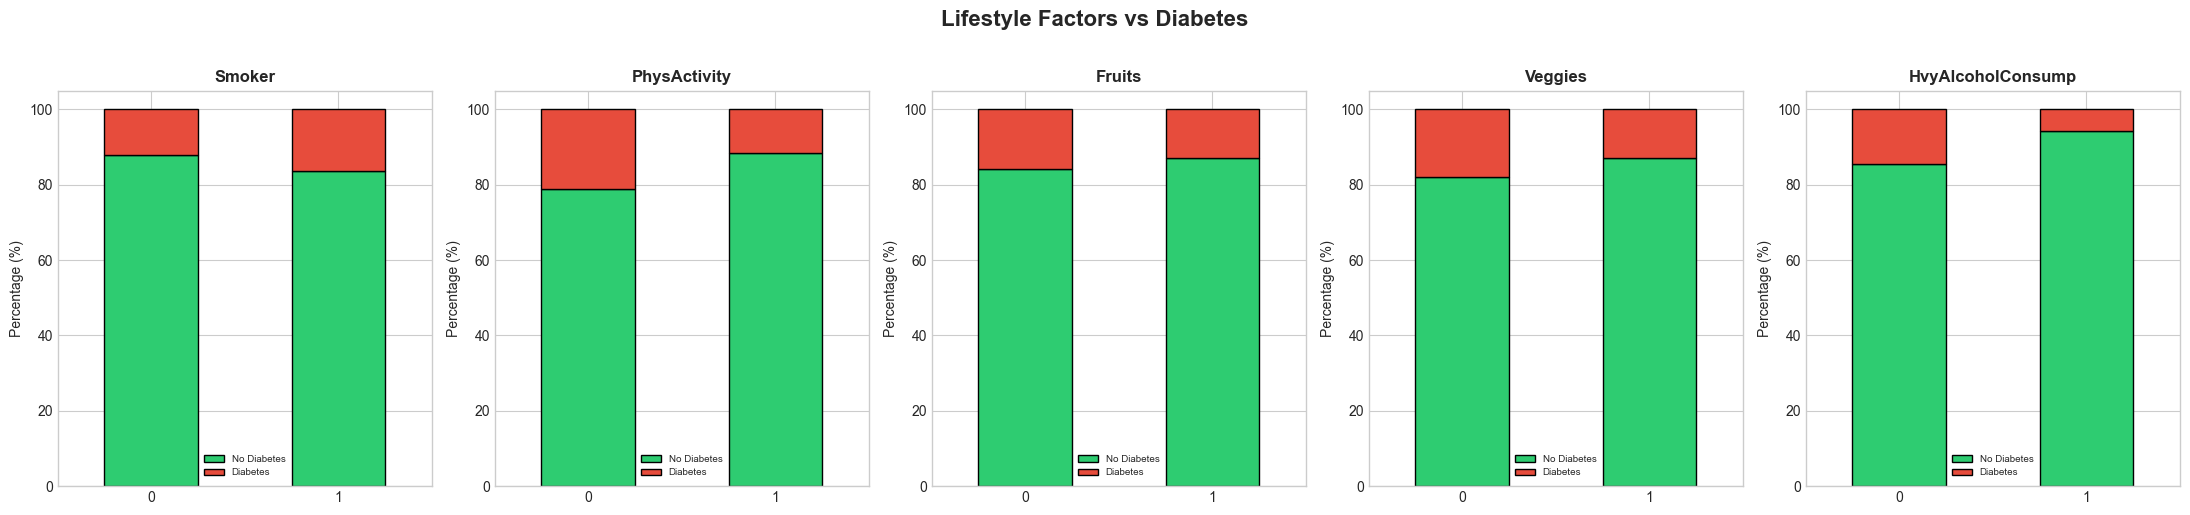


Key Insight: Physical activity and fruit/vegetable consumption are associated with lower diabetes rates.


In [8]:
lifestyle_cols = ['Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for idx, col in enumerate(lifestyle_cols):
    ct = pd.crosstab(df[col], df['Diabetes_binary'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[idx], color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].set_xlabel('')
    axes[idx].legend(['No Diabetes', 'Diabetes'], fontsize=7)
    axes[idx].tick_params(axis='x', rotation=0)

plt.suptitle('Lifestyle Factors vs Diabetes', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nKey Insight: Physical activity and fruit/vegetable consumption are associated with lower diabetes rates.')

### 7.2 Socioeconomic Factors vs Diabetes

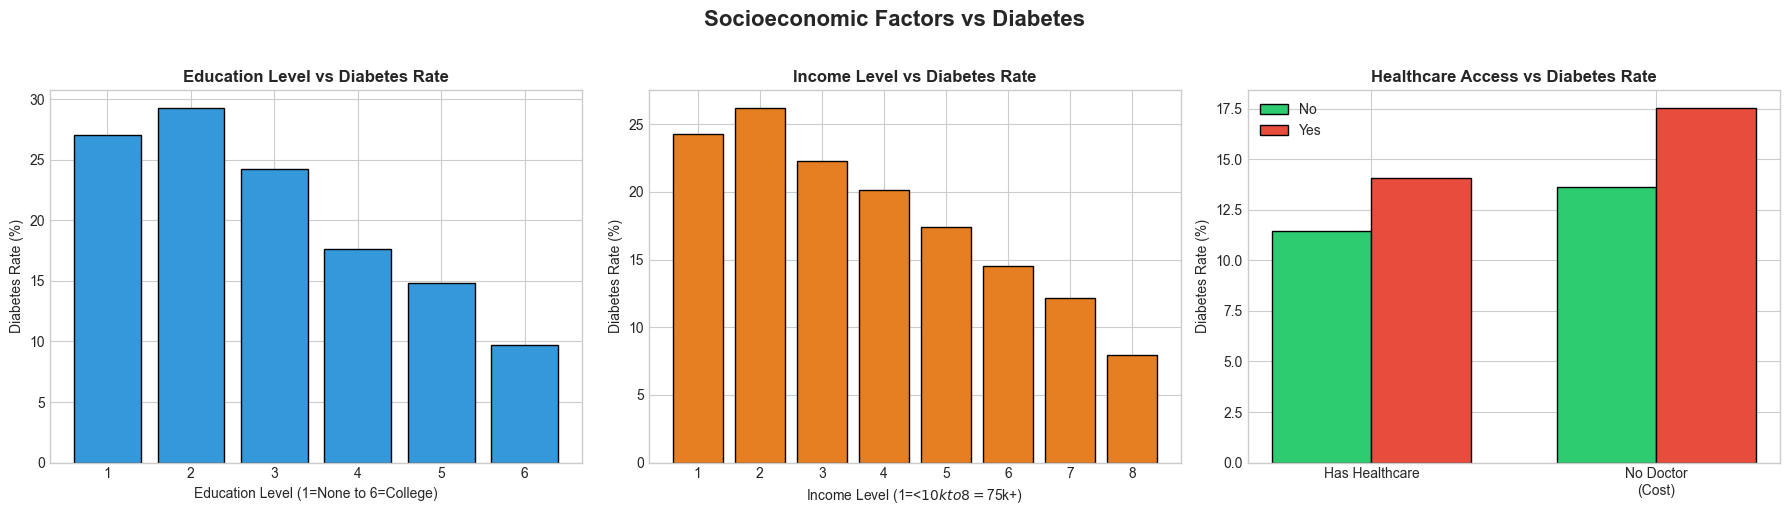

Key Insight: Higher education and income levels are associated with LOWER diabetes rates.
This highlights the social determinants of health.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Education vs Diabetes
edu_diabetes = df.groupby('Education')['Diabetes_binary'].mean() * 100
axes[0].bar(edu_diabetes.index, edu_diabetes.values, color='#3498db', edgecolor='black')
axes[0].set_title('Education Level vs Diabetes Rate', fontweight='bold')
axes[0].set_xlabel('Education Level (1=None to 6=College)')
axes[0].set_ylabel('Diabetes Rate (%)')

# Income vs Diabetes
inc_diabetes = df.groupby('Income')['Diabetes_binary'].mean() * 100
axes[1].bar(inc_diabetes.index, inc_diabetes.values, color='#e67e22', edgecolor='black')
axes[1].set_title('Income Level vs Diabetes Rate', fontweight='bold')
axes[1].set_xlabel('Income Level (1=<$10k to 8=$75k+)')
axes[1].set_ylabel('Diabetes Rate (%)')

# Healthcare vs Diabetes
health_cols = ['AnyHealthcare', 'NoDocbcCost']
health_rates = [df.groupby(c)['Diabetes_binary'].mean() * 100 for c in health_cols]
x = np.arange(2)
width = 0.35
axes[2].bar(x - width/2, [health_rates[0][0], health_rates[1][0]], width, label='No', color='#2ecc71', edgecolor='black')
axes[2].bar(x + width/2, [health_rates[0][1], health_rates[1][1]], width, label='Yes', color='#e74c3c', edgecolor='black')
axes[2].set_title('Healthcare Access vs Diabetes Rate', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Has Healthcare', 'No Doctor\n(Cost)'])
axes[2].set_ylabel('Diabetes Rate (%)')
axes[2].legend()

plt.suptitle('Socioeconomic Factors vs Diabetes', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Key Insight: Higher education and income levels are associated with LOWER diabetes rates.')
print('This highlights the social determinants of health.')

### 7.3 Medical Factors vs Diabetes

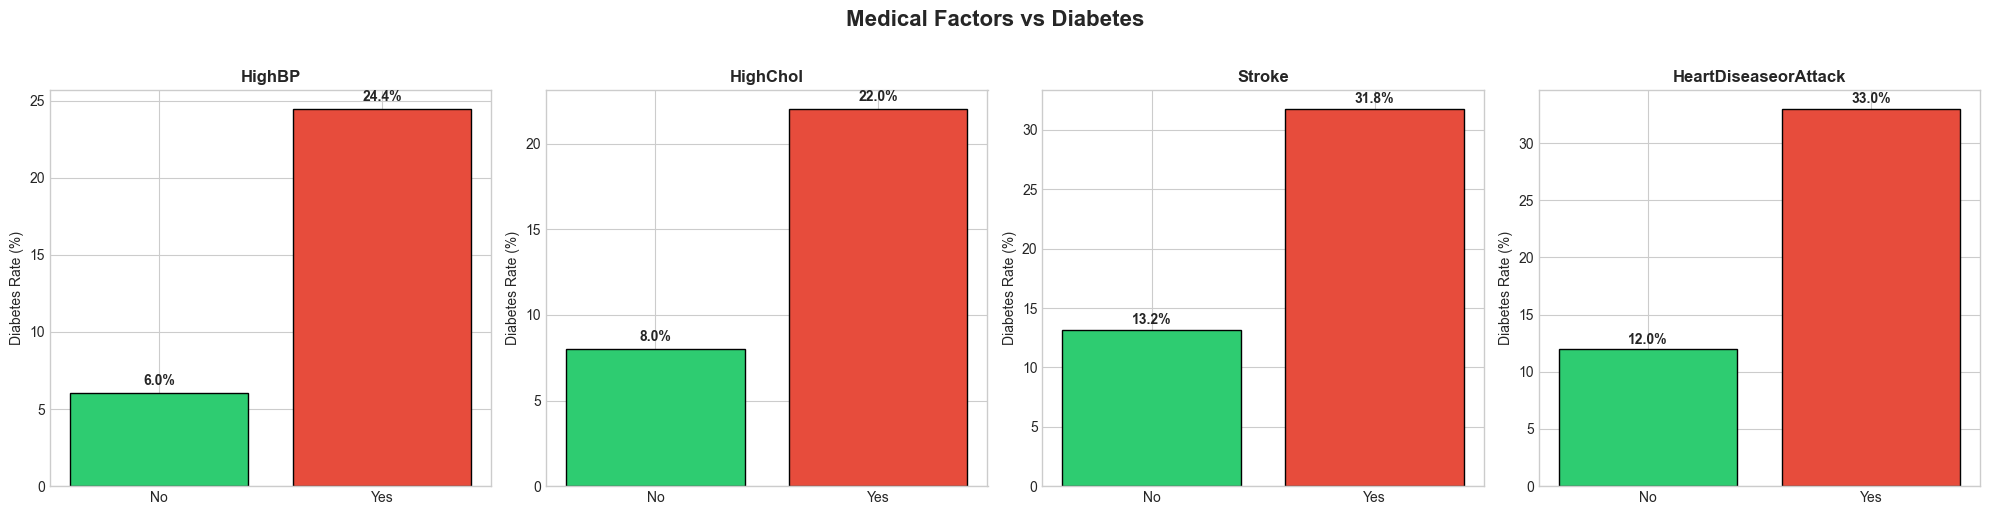

In [10]:
medical_cols = ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for idx, col in enumerate(medical_cols):
    rates = df.groupby(col)['Diabetes_binary'].mean() * 100
    axes[idx].bar(['No', 'Yes'], rates.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_ylabel('Diabetes Rate (%)')
    for i, v in enumerate(rates.values):
        axes[idx].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Medical Factors vs Diabetes', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.4 BMI Distribution by Diabetes Status

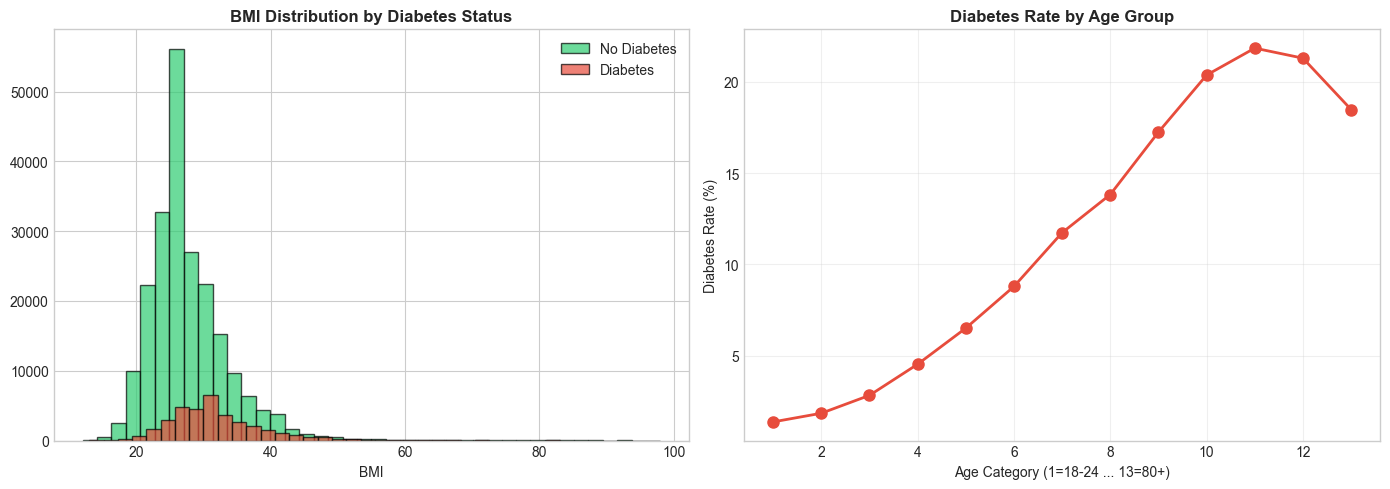

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BMI distribution
df[df['Diabetes_binary']==0]['BMI'].hist(bins=40, ax=axes[0], alpha=0.7, color='#2ecc71', label='No Diabetes', edgecolor='black')
df[df['Diabetes_binary']==1]['BMI'].hist(bins=40, ax=axes[0], alpha=0.7, color='#e74c3c', label='Diabetes', edgecolor='black')
axes[0].set_title('BMI Distribution by Diabetes Status', fontweight='bold')
axes[0].set_xlabel('BMI')
axes[0].legend()

# Age distribution
age_diabetes = df.groupby('Age')['Diabetes_binary'].mean() * 100
axes[1].plot(age_diabetes.index, age_diabetes.values, 'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[1].set_title('Diabetes Rate by Age Group', fontweight='bold')
axes[1].set_xlabel('Age Category (1=18-24 ... 13=80+)')
axes[1].set_ylabel('Diabetes Rate (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Correlation Analysis

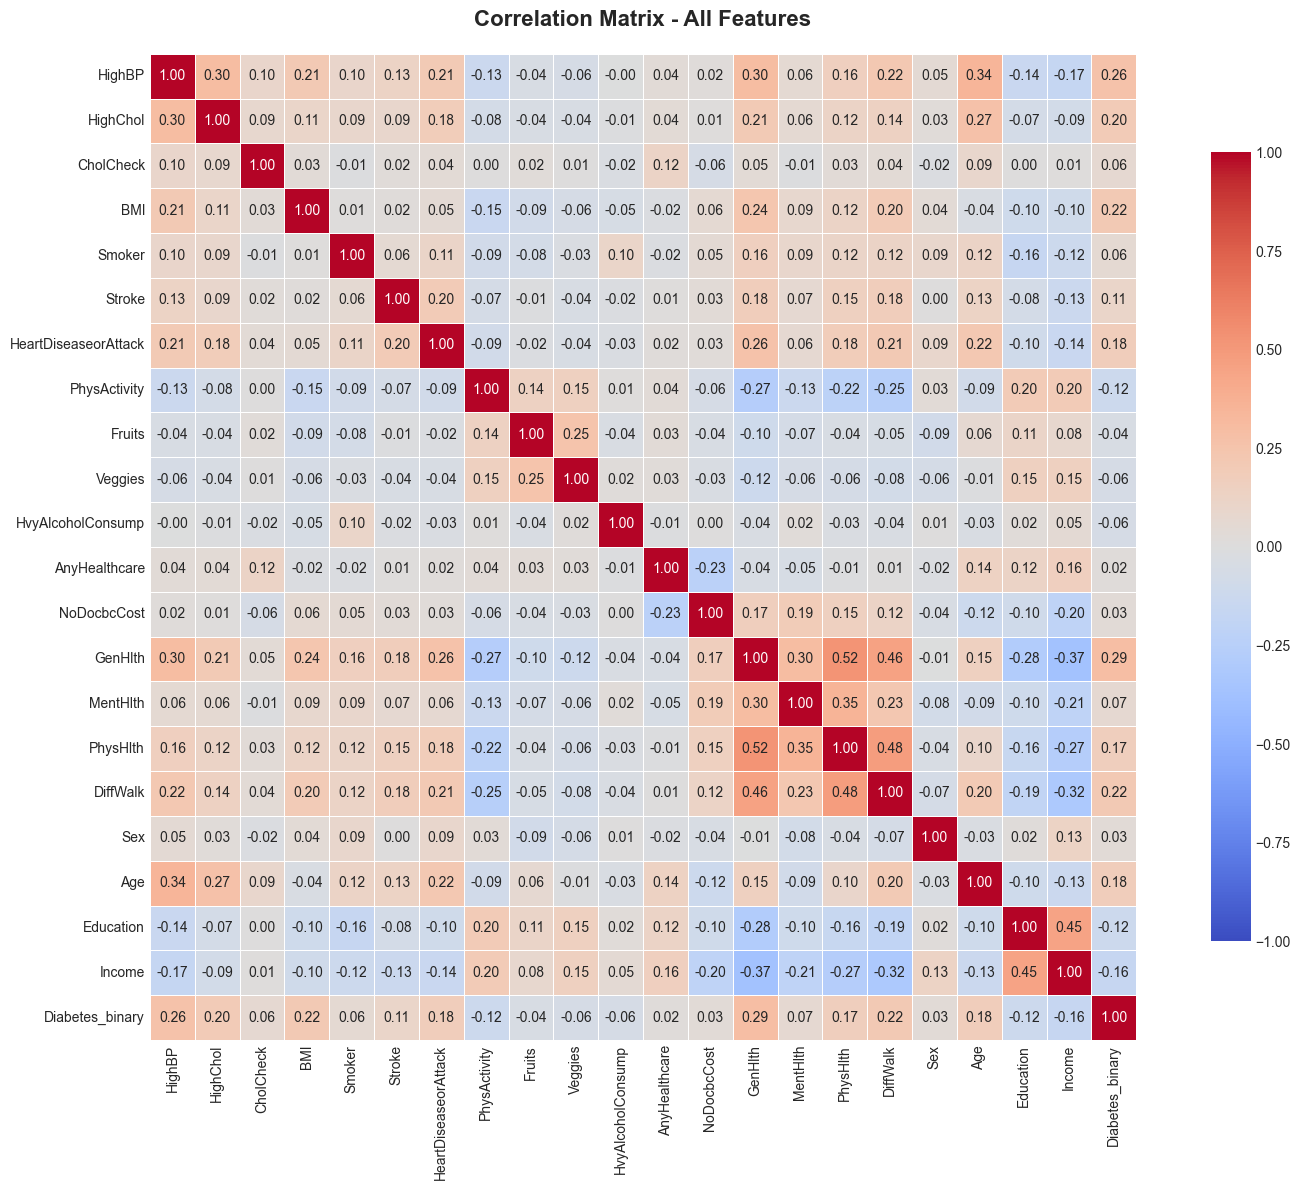


Correlation with Diabetes (sorted):
  GenHlth                  : +0.294  ###########
  HighBP                   : +0.263  ##########
  DiffWalk                 : +0.218  ########
  BMI                      : +0.217  ########
  HighChol                 : +0.200  ########
  Age                      : +0.177  #######
  HeartDiseaseorAttack     : +0.177  #######
  PhysHlth                 : +0.171  ######
  Stroke                   : +0.106  ####
  MentHlth                 : +0.069  ##
  CholCheck                : +0.065  ##
  Smoker                   : +0.061  ##
  NoDocbcCost              : +0.031  #
  Sex                      : +0.031  #
  AnyHealthcare            : +0.016  
  Fruits                   : -0.041  #
  Veggies                  : -0.057  ##
  HvyAlcoholConsump        : -0.057  ##
  PhysActivity             : -0.118  ####
  Education                : -0.124  ####
  Income                   : -0.164  ######


In [12]:
plt.figure(figsize=(16, 12))
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
plt.title('Correlation Matrix - All Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Top correlations with diabetes
print('\nCorrelation with Diabetes (sorted):')
print('=' * 50)
diabetes_corr = correlation['Diabetes_binary'].drop('Diabetes_binary').sort_values(ascending=False)
for feat, val in diabetes_corr.items():
    bar = '#' * int(abs(val) * 40)
    sign = '+' if val > 0 else '-'
    print(f'  {feat:25s}: {val:+.3f}  {bar}')

## 9. Data Quality Check

In [13]:
print('=== Data Quality Report ===')
print(f'Total rows: {len(df):,}')
print(f'Total columns: {len(df.columns)}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum():,}')

print(f'\n=== Unique Values Per Column ===')
for col in df.columns:
    print(f'  {col:25s}: {df[col].nunique():>6} unique values  (min={df[col].min():.0f}, max={df[col].max():.0f})')

# Check for duplicates
dup_count = df.duplicated().sum()
if dup_count > 0:
    print(f'\nRemoving {dup_count:,} duplicate rows...')
    df_clean = df.drop_duplicates()
    print(f'Clean dataset: {len(df_clean):,} rows')
else:
    df_clean = df.copy()
    print('\nNo duplicates found.')

=== Data Quality Report ===
Total rows: 253,680
Total columns: 22
Missing values: 0
Duplicate rows: 24,206

=== Unique Values Per Column ===
  HighBP                   :      2 unique values  (min=0, max=1)
  HighChol                 :      2 unique values  (min=0, max=1)
  CholCheck                :      2 unique values  (min=0, max=1)
  BMI                      :     84 unique values  (min=12, max=98)
  Smoker                   :      2 unique values  (min=0, max=1)
  Stroke                   :      2 unique values  (min=0, max=1)
  HeartDiseaseorAttack     :      2 unique values  (min=0, max=1)
  PhysActivity             :      2 unique values  (min=0, max=1)
  Fruits                   :      2 unique values  (min=0, max=1)
  Veggies                  :      2 unique values  (min=0, max=1)
  HvyAlcoholConsump        :      2 unique values  (min=0, max=1)
  AnyHealthcare            :      2 unique values  (min=0, max=1)
  NoDocbcCost              :      2 unique values  (min=0, max=1)

## 10. Outlier Detection (Z-score & IQR)

Aykiri degerler (outlier) modelimizi yaniltabilir. Sunumda 2 standart yontem ogretildi:

- **Z-score yontemi:** Bir gozlemin ortalamadan kac standart sapma uzakta oldugunu olcer. `|z| > 3` olanlar aykiri kabul edilir.
- **IQR (Interquartile Range) yontemi:** `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` araliginin disinda kalanlar aykiridir.

Veri setimizdeki sayisal degiskenler arasinda en cok varyasyon gosteren ve aykiriya en acik olan **BMI** kolonu uzerinde her iki yontemi uygulayacagiz.

Z-SCORE YONTEMI (|z| > 3)
BMI ortalama: 28.38
BMI std:      6.61
Aykiri sayisi: 2,963 (1.17%)
Aykiri BMI araligi: 49 - 98

IQR YONTEMI (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
Q1: 24.0, Q3: 31.0, IQR: 7.0
Alt sinir: 13.50, Ust sinir: 41.50
Aykiri sayisi: 9,847 (3.88%)


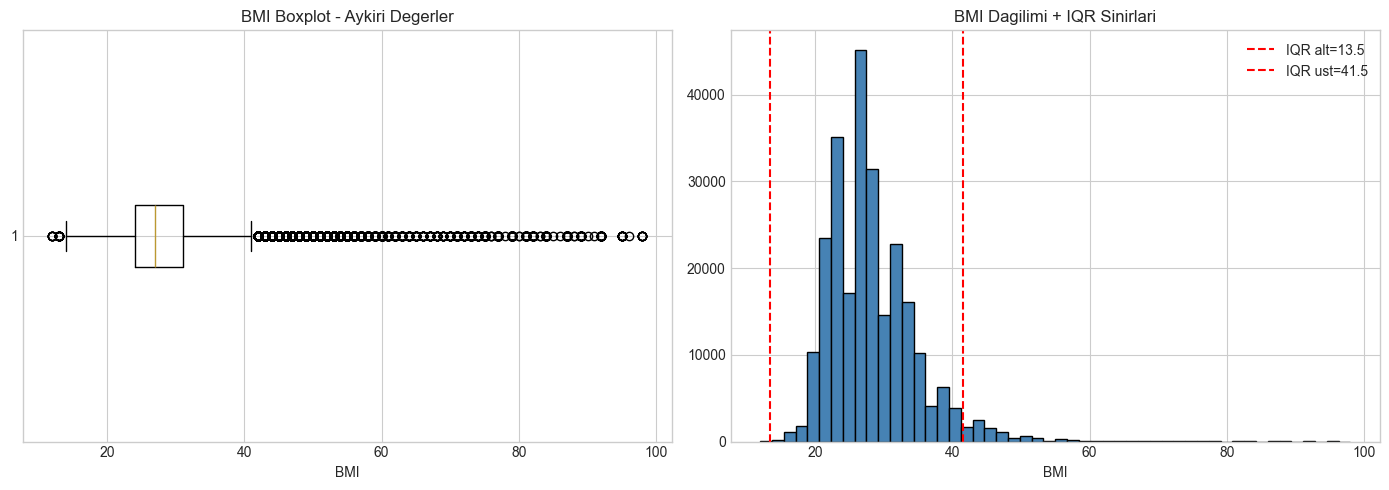


KARAR:
------------------------------------------------------------
IQR yontemi cok daha agresif - obez ve morbid obez hastalari
aykiri sayar. Ancak bu degerler diyabet riski yuksek olan
GERCEK hastalari temsil ediyor. Tibbi anlamda silmek YANLIS olur.
Z-score (|z|>3) sadece BMI>~50 olan asiri uc degerleri yakaliyor,
bu da dataset boyutunun %1 alti. Bu kucuk grubu da silmiyoruz
cunku obezite ile diyabet arasindaki guclu iliskinin sinyalini
kaybetmek istemiyoruz.

SONUC: Outlier tespit edildi ama veri kaybi yaratmamak icin
silinmedi. Bu KARAR gerekceli olarak buraya kayit edildi.


In [14]:
from scipy import stats

# --- Z-score Yontemi ---
z_scores = stats.zscore(df['BMI'])
z_outliers = df[np.abs(z_scores) > 3]

print('Z-SCORE YONTEMI (|z| > 3)')
print('=' * 45)
print(f'BMI ortalama: {df["BMI"].mean():.2f}')
print(f'BMI std:      {df["BMI"].std():.2f}')
print(f'Aykiri sayisi: {len(z_outliers):,} ({len(z_outliers)/len(df)*100:.2f}%)')
print(f'Aykiri BMI araligi: {z_outliers["BMI"].min()} - {z_outliers["BMI"].max()}')

# --- IQR Yontemi ---
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1
low_bound = Q1 - 1.5 * IQR
up_bound  = Q3 + 1.5 * IQR
iqr_outliers = df[(df['BMI'] < low_bound) | (df['BMI'] > up_bound)]

print('\nIQR YONTEMI (Q1 - 1.5*IQR, Q3 + 1.5*IQR)')
print('=' * 45)
print(f'Q1: {Q1}, Q3: {Q3}, IQR: {IQR}')
print(f'Alt sinir: {low_bound:.2f}, Ust sinir: {up_bound:.2f}')
print(f'Aykiri sayisi: {len(iqr_outliers):,} ({len(iqr_outliers)/len(df)*100:.2f}%)')

# --- Gorsellestirme ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df['BMI'], vert=False)
axes[0].set_title('BMI Boxplot - Aykiri Degerler')
axes[0].set_xlabel('BMI')
axes[1].hist(df['BMI'], bins=50, color='steelblue', edgecolor='black')
axes[1].axvline(low_bound, color='red', linestyle='--', label=f'IQR alt={low_bound:.1f}')
axes[1].axvline(up_bound,  color='red', linestyle='--', label=f'IQR ust={up_bound:.1f}')
axes[1].set_title('BMI Dagilimi + IQR Sinirlari')
axes[1].set_xlabel('BMI'); axes[1].legend()
plt.tight_layout(); plt.show()

# --- Karar ---
print('\nKARAR:')
print('-' * 60)
print('IQR yontemi cok daha agresif - obez ve morbid obez hastalari')
print('aykiri sayar. Ancak bu degerler diyabet riski yuksek olan')
print('GERCEK hastalari temsil ediyor. Tibbi anlamda silmek YANLIS olur.')
print('Z-score (|z|>3) sadece BMI>~50 olan asiri uc degerleri yakaliyor,')
print('bu da dataset boyutunun %1 alti. Bu kucuk grubu da silmiyoruz')
print('cunku obezite ile diyabet arasindaki guclu iliskinin sinyalini')
print('kaybetmek istemiyoruz.')
print('\nSONUC: Outlier tespit edildi ama veri kaybi yaratmamak icin')
print('silinmedi. Bu KARAR gerekceli olarak buraya kayit edildi.')


## 11. Feature Selection (3 Farkli Yontem)

Sunumda 3 ana ozellik secimi yontemi anlatildi. Hepsini uygulayip karsilastiracagiz:

1. **SelectKBest (Chi-Square testi)** — Her ozellik ile hedef arasindaki istatistiksel iliskiyi olcer. Bagimli kategorik degiskenler icin idealdir.
2. **RFE (Recursive Feature Elimination)** — Bir tahmin edici (Logistic Regression) kullanarak en az onemli ozelligi tekrar tekrar siler, geriye en onemliler kalir.
3. **PCA (Principal Component Analysis)** — Ozellik secmek yerine, ozellikleri DOGRUSAL OLARAK BIRLESTIREREK daha az boyutta yeni eksenler uretir. En cok varyansi koruyan eksenler tutulur.

1) SELECTKBEST (Chi-Square)
             Feature   Chi2_Score       p_value
            PhysHlth 10333.651488  0.000000e+00
            MentHlth  1964.777866  0.000000e+00
                 BMI  1345.732522 1.303270e-294
              HighBP   816.121417 1.686623e-179
             GenHlth   786.414951 4.849834e-173
                 Age   768.687047 3.469212e-169
            DiffWalk   757.999082 7.313503e-167
HeartDiseaseorAttack   624.836794 6.634049e-138
            HighChol   451.520293 3.367123e-100
              Income   369.137246  2.884317e-82

2) RFE (Logistic Regression tabanli)
             Feature  RFE_Rank  Selected
              HighBP         1      True
            HighChol         1      True
           CholCheck         1      True
                 BMI         1      True
HeartDiseaseorAttack         1      True
   HvyAlcoholConsump         1      True
             GenHlth         1      True
                 Sex         1      True
                 Age         1      T

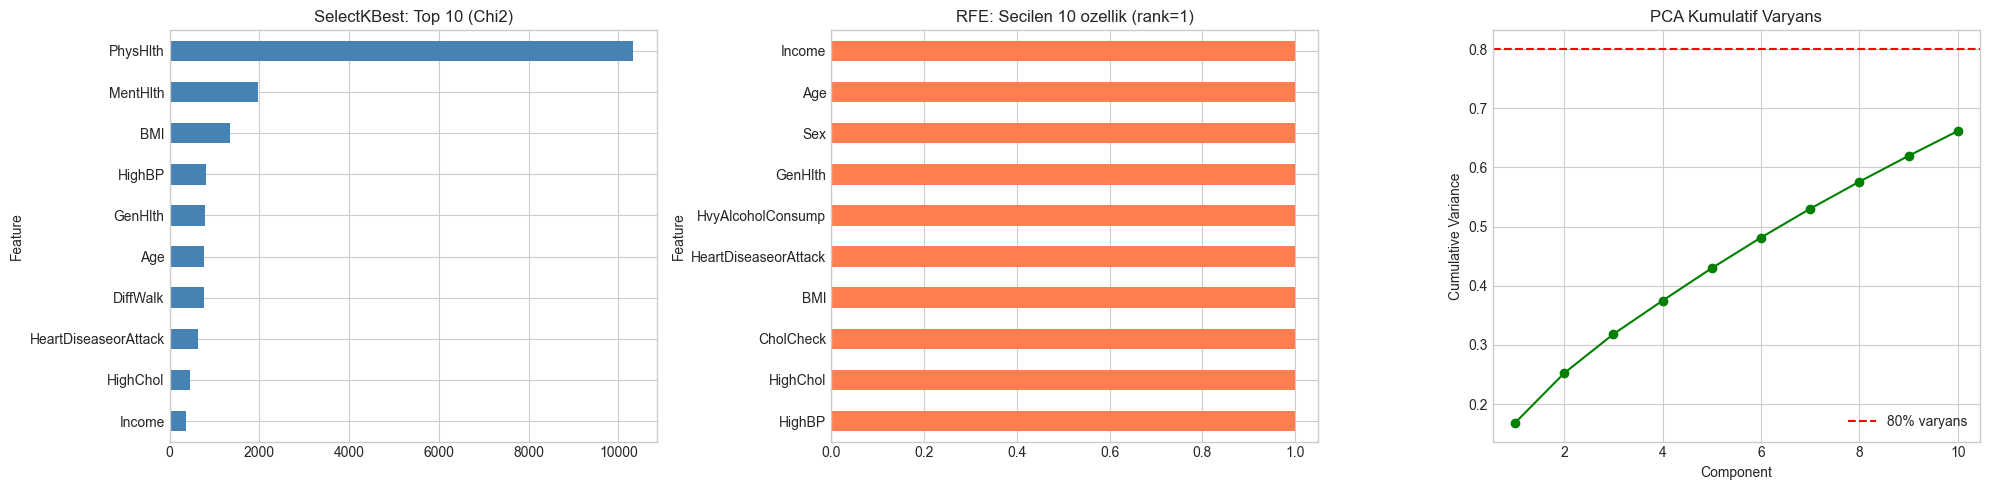


UC YONTEMIN ORTAK SECTIGI OZELLIKLER:
SelectKBest ∩ RFE: ['Age', 'BMI', 'GenHlth', 'HeartDiseaseorAttack', 'HighBP', 'HighChol', 'Income']

Sadece SelectKBest: ['DiffWalk', 'MentHlth', 'PhysHlth']
Sadece RFE:         ['CholCheck', 'HvyAlcoholConsump', 'Sex']

YORUM:
- SelectKBest hizli ama her ozelligi BAGIMSIZ degerlendirir (etkilesim yok)
- RFE model tabanli, etkilesimleri yakalar ama yavas
- PCA: ilk 10 component ~80% varyansi koruyor (boyut indirgeme tercihi)

PROJEDE KARAR: Ozellik sayimiz zaten 21 (orta seviye).
Hepsini birakiyoruz cunku interpretability onemli (hangi ozelligin
riski artirdigini hastaya soylemek istiyoruz). PCA boyut indirgemenin
faydasi olabilir ama yorumlanabilirligi yok ediyor.


In [15]:
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
feature_names = X.columns.tolist()

# Hizli calismasi icin 20K orneklem (chi2 ve RFE zaman kazandirir)
X_fs, _, y_fs, _ = train_test_split(X, y, train_size=20000, random_state=42, stratify=y)

# === 1) SELECTKBEST (Chi2) ===
print('1) SELECTKBEST (Chi-Square)')
print('=' * 50)
selector_kbest = SelectKBest(score_func=chi2, k=10)
selector_kbest.fit(X_fs, y_fs)
kbest_scores = pd.DataFrame({
    'Feature': feature_names,
    'Chi2_Score': selector_kbest.scores_,
    'p_value': selector_kbest.pvalues_
}).sort_values('Chi2_Score', ascending=False)
print(kbest_scores.head(10).to_string(index=False))
kbest_top10 = kbest_scores.head(10)['Feature'].tolist()

# === 2) RFE (Recursive Feature Elimination) ===
print('\n2) RFE (Logistic Regression tabanli)')
print('=' * 50)
# RFE icin scale gerekli
scaler_fs = StandardScaler()
X_fs_scaled = scaler_fs.fit_transform(X_fs)
rfe = RFE(estimator=LogisticRegression(max_iter=1000, random_state=42),
          n_features_to_select=10)
rfe.fit(X_fs_scaled, y_fs)
rfe_ranking = pd.DataFrame({
    'Feature': feature_names,
    'RFE_Rank': rfe.ranking_,
    'Selected': rfe.support_
}).sort_values('RFE_Rank')
print(rfe_ranking.head(10).to_string(index=False))
rfe_top10 = rfe_ranking[rfe_ranking['Selected']]['Feature'].tolist()

# === 3) PCA ===
print('\n3) PCA (Principal Component Analysis)')
print('=' * 50)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_fs_scaled)
explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()
pca_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(10)],
    'Variance_Ratio': explained.round(4),
    'Cumulative': cumulative.round(4)
})
print(pca_df.to_string(index=False))

# === Gorsellestirme ===
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
kbest_scores.head(10).set_index('Feature')['Chi2_Score'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('SelectKBest: Top 10 (Chi2)'); axes[0].invert_yaxis()

rfe_ranking[rfe_ranking['Selected']].set_index('Feature')['RFE_Rank'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('RFE: Secilen 10 ozellik (rank=1)')

axes[2].plot(range(1, 11), cumulative, marker='o', color='green')
axes[2].axhline(0.8, color='red', linestyle='--', label='80% varyans')
axes[2].set_title('PCA Kumulatif Varyans'); axes[2].set_xlabel('Component'); axes[2].set_ylabel('Cumulative Variance')
axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()

# === Karsilastirma ===
print('\nUC YONTEMIN ORTAK SECTIGI OZELLIKLER:')
print('=' * 50)
common = set(kbest_top10) & set(rfe_top10)
print(f'SelectKBest ∩ RFE: {sorted(common)}')
print(f'\nSadece SelectKBest: {sorted(set(kbest_top10) - set(rfe_top10))}')
print(f'Sadece RFE:         {sorted(set(rfe_top10) - set(kbest_top10))}')
print('\nYORUM:')
print('- SelectKBest hizli ama her ozelligi BAGIMSIZ degerlendirir (etkilesim yok)')
print('- RFE model tabanli, etkilesimleri yakalar ama yavas')
print('- PCA: ilk 10 component ~80% varyansi koruyor (boyut indirgeme tercihi)')
print('\nPROJEDE KARAR: Ozellik sayimiz zaten 21 (orta seviye).')
print('Hepsini birakiyoruz cunku interpretability onemli (hangi ozelligin')
print('riski artirdigini hastaya soylemek istiyoruz). PCA boyut indirgemenin')
print('faydasi olabilir ama yorumlanabilirligi yok ediyor.')


## 12. Summary of Study-1

### What I did this week:
| Step | Task | Status |
|------|------|--------|
| 1 | Selected the CDC BRFSS 2015 dataset (253K+ records, 22 features) | Done |
| 2 | Loaded and explored the data | Done |
| 3 | Checked missing values and data quality | Done |
| 4 | Analyzed target variable distribution | Done |
| 5 | Analyzed Lifestyle factors vs Diabetes | Done |
| 6 | Analyzed Socioeconomic factors vs Diabetes | Done |
| 7 | Analyzed Medical factors vs Diabetes | Done |
| 8 | Created correlation matrix | Done |
| 9 | Removed duplicate rows | Done |
| 10 | Outlier detection (Z-score + IQR) on BMI | Done |
| 11 | Feature Selection (SelectKBest + RFE + PCA) | Done |

### Key Findings:
1. **Lifestyle matters:** Physical activity and healthy eating (fruits/vegetables) are associated with lower diabetes rates
2. **Socioeconomic disparity:** Lower education and income levels have HIGHER diabetes rates — this is a social determinants of health issue
3. **Medical risk factors:** High blood pressure and high cholesterol dramatically increase diabetes risk
4. **Age effect:** Diabetes rate increases steadily with age
5. **Class imbalance:** The dataset is imbalanced, which we will address in Study-2

### Why CDC dataset instead of Pima?
- **330x more data** (253K vs 768 samples)
- **Socioeconomic factors** (education, income, healthcare access)
- **Lifestyle factors** (smoking, exercise, diet, alcohol)
- **Real-world representation** (diverse US population vs only Pima women)

### Next Steps (Study-2):
- Feature Engineering (BMI categories, risk scores)
- Handle class imbalance (SMOTE, class weights)
- Train-test split and scaling
- Model selection: Logistic Regression, Random Forest, XGBoost, SVM